### Boilerplate code - llm initiation

In [2]:
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_openai import ChatOpenAI
import os
from dotenv import load_dotenv
from langchain_ollama import ChatOllama

load_dotenv("./env")

google_api_key = os.getenv("GOOGLE_API_KEY")
openai_api_key = os.getenv("OPENAI_API_KEY")

google_llm = ChatGoogleGenerativeAI(
    temperature=0, 
    model="gemini-2.5-flash", 
    api_key=google_api_key,
    max_tokens=200
)

openai_llm = ChatOpenAI(
    temperature=0, 
    model="gpt-5-mini", 
    api_key=openai_api_key
)

ollama_llm = ChatOllama(
    model="llama3.1:latest",
    temperature=0
)

# ollama_llm.invoke("I am from Mars").content

In [3]:
from langchain_openai import ChatOpenAI

def multiply(a: int, b: int) -> int:
    """Multiply a and b.

    Args:
        a: first int
        b: second int
    """
    return a * b

# This will be a tool
def add(a: int, b: int) -> int:
    """Adds a and b.

    Args:
        a: first int
        b: second int
    """
    return a + b

def divide(a: int, b: int) -> float:
    """Divide a by b.

    Args:
        a: first int
        b: second int
    """
    return a / b

tools = [add, multiply, divide]
llm_with_tools = google_llm.bind_tools(tools)

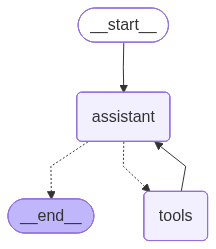

In [4]:
from IPython.display import Image, display

from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import MessagesState
from langgraph.graph import START, END, StateGraph
from langgraph.prebuilt import tools_condition, ToolNode

from langchain_core.messages import AIMessage, HumanMessage, SystemMessage

# System message
sys_msg = SystemMessage(content="You are a helpful assistant tasked with performing arithmetic on a set of inputs.")

# Node
def assistant(state: MessagesState):
   return {"messages": [llm_with_tools.invoke([sys_msg] + state["messages"])]}

# Graph
builder = StateGraph(MessagesState)

# Define nodes: these do the work
builder.add_node("assistant", assistant)
builder.add_node("tools", ToolNode(tools))

# Define edges: these determine the control flow
builder.add_edge(START, "assistant")
builder.add_conditional_edges(
    "assistant",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition,
)
builder.add_edge("tools", "assistant")

memory = MemorySaver()
graph = builder.compile(checkpointer=MemorySaver())

# Show
display(Image(graph.get_graph(xray=True).draw_mermaid_png()))

In [5]:
# Input
initial_input = {"messages": HumanMessage(content="Multiply 2 and 3")}

# Thread
thread = {"configurable": {"thread_id": "1"}}

# Run the graph until the first interruption
for event in graph.stream(initial_input, thread, stream_mode="values"):
    event['messages'][-1].pretty_print()

================================ Human Message =================================

Multiply 2 and 3
================================== Ai Message ==================================
Tool Calls:
  multiply (c07a526f-1260-4ccf-b8bb-388dc16d2172)
 Call ID: c07a526f-1260-4ccf-b8bb-388dc16d2172
  Args:
    a: 2
    b: 3
================================= Tool Message =================================
Name: multiply

6
================================== Ai Message ==================================

The product of 2 and 3 is 6.


###  Browsing the state history of our agent. (.get_state & .get_state_history)

In [17]:
current_state = graph.get_state(thread)
for msg in current_state.values.get('messages'):
    msg.pretty_print()

================================ Human Message =================================

Multiply 2 and 3
================================== Ai Message ==================================
Tool Calls:
  multiply (c07a526f-1260-4ccf-b8bb-388dc16d2172)
 Call ID: c07a526f-1260-4ccf-b8bb-388dc16d2172
  Args:
    a: 2
    b: 3
================================= Tool Message =================================
Name: multiply

6
================================== Ai Message ==================================

The product of 2 and 3 is 6.


In [20]:
all_states = [s for s in graph.get_state_history(thread)]
all_states

[StateSnapshot(values={'messages': [HumanMessage(content='Multiply 2 and 3', additional_kwargs={}, response_metadata={}, id='04b4a427-e8e9-4915-8500-7d68a0a19cdf'), AIMessage(content='', additional_kwargs={'function_call': {'name': 'multiply', 'arguments': '{"a": 2, "b": 3}'}, '__gemini_function_call_thought_signatures__': {'3670ed16-4665-465c-9d85-e27a2e10befc': 'CoMCAQw51seHH7CMCn5sYEOte9mNzgvcPXblz/mJLsCUD81w7pvgqTHYnqa36BmZwBRKbcHkAwdfp8DYpG+s+sHsb1NMoqhNl4fYHkVzDVAkUudFWbVzsQkysm2OxbLyNQEwabxFAQq1ioAcizLyOXAJ+LW3m5T5fapg/hYE88MD8HHuXB4XDjLjd0Z7kKHpICvparSvSN99jUCu2HKAqJ+EiAAcID2fCkuszXGV/QFV5uqm2SnuLKHQibcaaBH/FEPJImA9Eah/HQRx88aTctPIOaO5G0KoJ3uUko7hx+eRtTgubaQfzh0JbNHRn7vstLSD9DaCqbNs/dl6POY1bWKPcACKtg=='}}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019d9d45-c542-7532-addc-01d54bb94840-0', tool_calls=[{'name': 'multiply', 'args': {'a': 2, 'b': 3}, 'id': '3670ed16-4665-465c-9d8

### States are updated in order i.e Newest to the oldest
- ##### We chose [-2] as it is the meaningful first state. 
- ##### [-1] is Langgraph's empty/blank state at graph initialization

In [8]:
to_replay = all_states[-2]
to_replay

StateSnapshot(values={'messages': [HumanMessage(content='Multiply 2 and 3', additional_kwargs={}, response_metadata={}, id='04b4a427-e8e9-4915-8500-7d68a0a19cdf')]}, next=('assistant',), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f13aa12-b101-69f0-8000-59a65135a946'}}, metadata={'source': 'loop', 'step': 0, 'parents': {}}, created_at='2026-04-17T21:05:31.181710+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f13aa12-b0ff-677c-bfff-8c3a4ed494af'}}, tasks=(PregelTask(id='d0dc16b9-1eed-f124-7680-45a7ff022945', name='assistant', path=('__pregel_pull', 'assistant'), error=None, interrupts=(), state=None, result={'messages': [AIMessage(content='', additional_kwargs={'function_call': {'name': 'multiply', 'arguments': '{"a": 2, "b": 3}'}, '__gemini_function_call_thought_signatures__': {'c07a526f-1260-4ccf-b8bb-388dc16d2172': 'CvwBAQw51sciraDeRQXDAOM5d/jSH2iLYWwkbummlbpohk9zKiyeeR/1xahd+f4yT1ePro/gCgvlyrhV

In [9]:
to_replay.values

{'messages': [HumanMessage(content='Multiply 2 and 3', additional_kwargs={}, response_metadata={}, id='04b4a427-e8e9-4915-8500-7d68a0a19cdf')]}

In [10]:
to_replay.next

('assistant',)

In [11]:
to_replay.config

{'configurable': {'thread_id': '1',
  'checkpoint_ns': '',
  'checkpoint_id': '1f13aa12-b101-69f0-8000-59a65135a946'}}

##### Replay - if we invoke again with config, it just replay's(rerun) from the the checkpoint_id

In [18]:
for event in graph.stream(None, to_replay.config, stream_mode="values"):
    event['messages'][-1].pretty_print()

================================ Human Message =================================

Multiply 2 and 3
================================== Ai Message ==================================
Tool Calls:
  multiply (3670ed16-4665-465c-9d85-e27a2e10befc)
 Call ID: 3670ed16-4665-465c-9d85-e27a2e10befc
  Args:
    a: 2
    b: 3
================================= Tool Message =================================
Name: multiply

6
================================== Ai Message ==================================

The product of 2 and 3 is 6.


### Forking a state (to replay with different value)

In [22]:
forked_state = all_states[-2]
forked_state.config

{'configurable': {'thread_id': '1',
  'checkpoint_ns': '',
  'checkpoint_id': '1f13aa12-b101-69f0-8000-59a65135a946'}}

In [23]:
forked_config = graph.update_state(
    forked_state.config,
    {"messages": [HumanMessage(content="Multiply 5 and 5",
    id=forked_state.values['messages'][0].id)]}
)
forked_config

{'configurable': {'thread_id': '1',
  'checkpoint_ns': '',
  'checkpoint_id': '1f13aa1f-9cf1-6098-8001-216543844b34'}}

In [24]:
all_states = [state for state in graph.get_state_history(thread) ]
all_states[0].values["messages"]

[HumanMessage(content='Multiply 5 and 5', additional_kwargs={}, response_metadata={}, id='04b4a427-e8e9-4915-8500-7d68a0a19cdf')]

In [25]:
graph.get_state({'configurable': {'thread_id': '1'}})

StateSnapshot(values={'messages': [HumanMessage(content='Multiply 5 and 5', additional_kwargs={}, response_metadata={}, id='04b4a427-e8e9-4915-8500-7d68a0a19cdf')]}, next=('assistant',), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f13aa1f-9cf1-6098-8001-216543844b34'}}, metadata={'source': 'update', 'step': 1, 'parents': {}}, created_at='2026-04-17T21:11:18.043862+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f13aa12-b101-69f0-8000-59a65135a946'}}, tasks=(PregelTask(id='13c3a557-bbd9-b5c0-80b1-6dace8e59ae3', name='assistant', path=('__pregel_pull', 'assistant'), error=None, interrupts=(), state=None, result=None),), interrupts=())

In [26]:
for event in graph.stream(None, forked_config, stream_mode="values"):
    event['messages'][-1].pretty_print()

================================ Human Message =================================

Multiply 5 and 5
================================== Ai Message ==================================
Tool Calls:
  multiply (59abbcaa-d5f9-4fac-a866-fc29c9c259de)
 Call ID: 59abbcaa-d5f9-4fac-a866-fc29c9c259de
  Args:
    a: 5
    b: 5
================================= Tool Message =================================
Name: multiply

25
================================== Ai Message ==================================

The product of 5 and 5 is 25.


#### Time travelling to previous runs - Change the index to see for yourself

In [55]:
state_history = [s for s in graph.get_state_history(thread)]
state_history

for msg in state_history[0].values.get('messages'):
    msg.pretty_print()

================================ Human Message =================================

Multiply 5 and 5
================================== Ai Message ==================================
Tool Calls:
  multiply (59abbcaa-d5f9-4fac-a866-fc29c9c259de)
 Call ID: 59abbcaa-d5f9-4fac-a866-fc29c9c259de
  Args:
    a: 5
    b: 5
================================= Tool Message =================================
Name: multiply

25
================================== Ai Message ==================================

The product of 5 and 5 is 25.
